# Importing Necessary Libraries

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

import os
from IPython.display import Audio, display

import pandas as pd
import numpy as np

# Preprocessing Data

In [2]:
base_path = "cv-corpus-24.0-2025-12-05\\xmf"
clips_path = os.path.join(base_path, "clips")

train = pd.read_csv(os.path.join(base_path, "train.tsv"), sep="\t")
dev = pd.read_csv(os.path.join(base_path, "dev.tsv"), sep="\t")
test = pd.read_csv(os.path.join(base_path, "test.tsv"), sep="\t")
validated = pd.read_csv(os.path.join(base_path, "validated.tsv"), sep="\t")
invalidated = pd.read_csv(os.path.join(base_path, "invalidated.tsv"), sep="\t")
other = pd.read_csv(os.path.join(base_path, "other.tsv"), sep="\t")
reported = pd.read_csv(os.path.join(base_path, "reported.tsv"), sep="\t")
clip_durations = pd.read_csv(os.path.join(base_path, "clip_durations.tsv"), sep="\t")
validated_sentences = pd.read_csv(os.path.join(base_path, "validated_sentences.tsv"), sep="\t")
unvalidated_sentences = pd.read_csv(os.path.join(base_path, "unvalidated_sentences.tsv"), sep="\t")


In [3]:
datasets = {
    "train": train,
    "dev": dev,
    "test": test,
    "validated": validated,
    "invalidated": invalidated,
    "other": other,
    "reported": reported
}

In [4]:
eda = {}

for name, df in datasets.items():
    info = {}
    info["rows"] = len(df)
    info["cols"] = df.shape[1]
    info["missing"] = df.isna().sum()
    info["duplicates"] = df.duplicated().sum()
    if "sentence" in df.columns:
        info["sentence_len"] = df["sentence"].astype(str).apply(len).describe()
        info["word_count"] = df["sentence"].astype(str).apply(lambda x: len(x.split())).describe()
    if "path" in df.columns:
        info["unique_clips"] = df["path"].nunique()
    eda[name] = info

duration_stats = clip_durations["duration[ms]"].describe()

## First off lets check out distribution of clip duration overally from all the sets

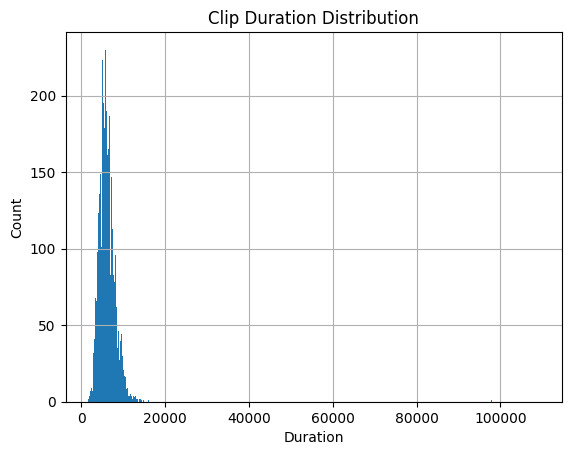

In [5]:
plt.figure()
clip_durations["duration[ms]"].hist(bins=1000)
plt.xlabel("Duration")
plt.ylabel("Count")
plt.title("Clip Duration Distribution")
plt.show()


## In total the dataset contains 12 hours of data

In [6]:
total_duration_ms = clip_durations["duration[ms]"].sum()
total_hours = total_duration_ms / 3600000

print("Total duration (ms):", total_duration_ms)
print("Total duration (hours):", total_hours)

Total duration (ms): 45608148
Total duration (hours): 12.66893


## The sentence lengths in the validated dataset range from 0 to 120 tokens, with the majority concentrated around 60.

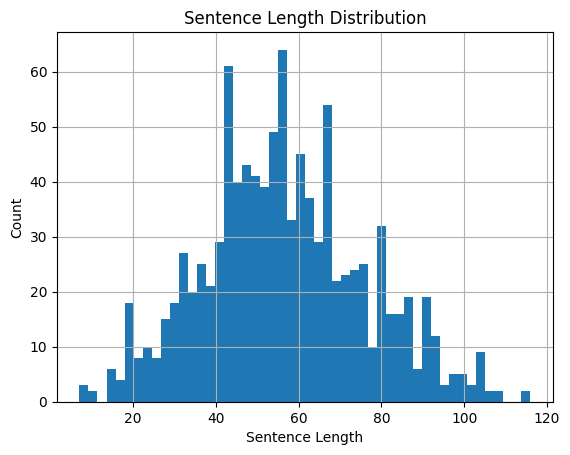

In [7]:
sent_lengths = validated_sentences["sentence"].astype(str).apply(len)

plt.figure()
sent_lengths.hist(bins=50)
plt.xlabel("Sentence Length")
plt.ylabel("Count")
plt.title("Sentence Length Distribution")
plt.show()

### Lets take a closer look to the unique characters in the datasets.

In [8]:
train_chars = set("".join(train["sentence"].astype(str)))
test_chars = set("".join(test["sentence"].astype(str)))

print("Train unique characters:", sorted(train_chars))
print("Test unique characters:", sorted(test_chars))

print("Train char count:", len(train_chars))
print("Test char count:", len(test_chars))

Train unique characters: [' ', '!', ',', '-', '.', ':', '?', 'ა', 'ბ', 'გ', 'დ', 'ე', 'ვ', 'ზ', 'თ', 'ი', 'კ', 'ლ', 'მ', 'ნ', 'ო', 'პ', 'ჟ', 'რ', 'ს', 'ტ', 'უ', 'ფ', 'ქ', 'ღ', 'ყ', 'შ', 'ჩ', 'ც', 'ძ', 'წ', 'ჭ', 'ხ', 'ჯ', 'ჰ', 'ჷ', 'ჸ']
Test unique characters: [' ', '!', ',', '-', '.', ':', '?', 'ა', 'ბ', 'გ', 'დ', 'ე', 'ვ', 'ზ', 'თ', 'ი', 'კ', 'ლ', 'მ', 'ნ', 'ო', 'პ', 'ჟ', 'რ', 'ს', 'ტ', 'უ', 'ფ', 'ქ', 'ღ', 'ყ', 'შ', 'ჩ', 'ც', 'ძ', 'წ', 'ჭ', 'ხ', 'ჯ', 'ჰ', 'ჲ', 'ჷ', 'ჸ', '“', '„']
Train char count: 42
Test char count: 45


### We have 3 distinct characters in mingrelian language, which do not appear in georgian language. There characters are 'ჲ', 'ჷ', 'ჸ'. To investigate their pronouncation and spelling, lets take a look at one sample for each character

In [9]:
chars_to_find = ['ჲ', 'ჷ', 'ჸ']
final_samples = []
used_paths = set() 

for char in chars_to_find:
    matches = test[
        test['sentence'].astype(str).str.contains(char, na=False) & 
        ~test['path'].isin(used_paths)
    ]
    
    found_valid = False
    
    for _, row in matches.iterrows():
        audio_path = os.path.join(clips_path, row['path'])
        
        try:
            y, sr = librosa.load(audio_path, sr=None)
            
            if len(y) == 0 or np.max(np.abs(y)) == 0 or np.isnan(y).any():
                print(f"Skipping silent/corrupted file for '{char}': {row['path']}")
                continue 
            
            final_samples.append((char, row, y, sr))
            used_paths.add(row['path'])
            found_valid = True
            break 
            
        except Exception as e:
            print(f"Error loading {row['path']}: {e}")
            continue
            
    if not found_valid:
        print(f"Could not find ANY valid audio for '{char}'.")


Skipping silent/corrupted file for 'ჸ': common_voice_xmf_42852333.mp3


▶️ Play audio for 'ჲ':


▶️ Play audio for 'ჷ':


▶️ Play audio for 'ჸ':


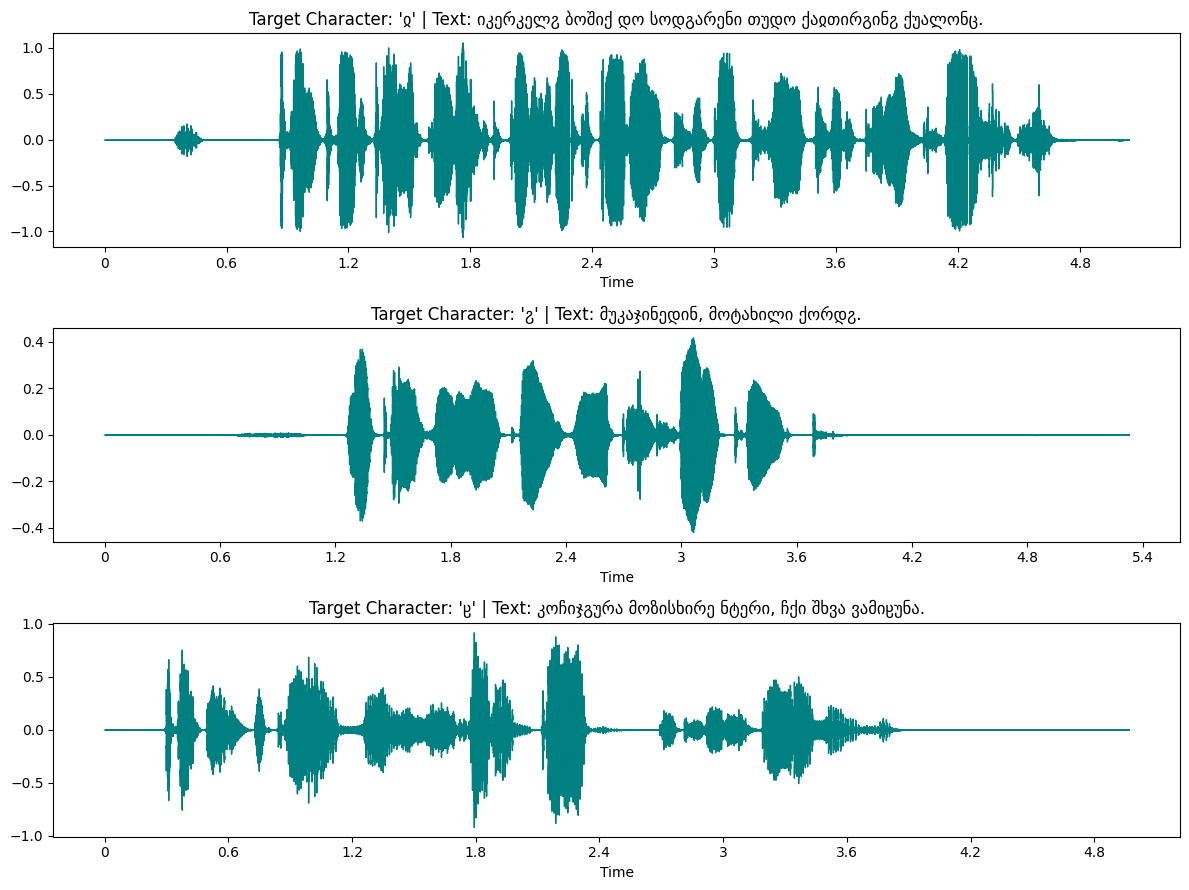

In [10]:
if final_samples:
    fig, axes = plt.subplots(len(final_samples), 1, figsize=(12, 3 * len(final_samples)))
    
    if len(final_samples) == 1: 
        axes = [axes]

    for i, (char, row, y, sr) in enumerate(final_samples):
        librosa.display.waveshow(y, sr=sr, ax=axes[i], color="teal")
        axes[i].set_title(f"Target Character: '{char}' | Text: {row['sentence']}")
        
        print(f"▶️ Play audio for '{char}':")
        display(Audio(data=y, rate=sr))

    plt.tight_layout()
    plt.show()

#### Lets add clip durations within real datasets

In [11]:
if 'clip' in clip_durations.columns:
    clip_durations = clip_durations.rename(columns={'clip': 'path'})

train = pd.merge(train, clip_durations, on="path", how="left")
dev = pd.merge(dev, clip_durations, on="path", how="left")
test = pd.merge(test, clip_durations, on="path", how="left")

### Statistical information about speakers

In [12]:
total_speakers = train['client_id'].nunique()
print(f"Total unique speakers in Train: {total_speakers}")

Total unique speakers in Train: 9


In [13]:
speaker_counts = train['client_id'].value_counts()
top_1_pct = (speaker_counts.iloc[0] / len(train)) * 100
top_5_pct = (speaker_counts.iloc[:5].sum() / len(train)) * 100

print(f"Top 1 speaker recorded {top_1_pct:.1f}% of the training data.")
print(f"Top 5 speakers recorded {top_5_pct:.1f}% of the training data.\n")

Top 1 speaker recorded 42.5% of the training data.
Top 5 speakers recorded 95.2% of the training data.



C:\Users\Asus\AppData\Local\Temp\ipykernel_9596\2234762832.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_labels, y=top_counts, palette="viridis")


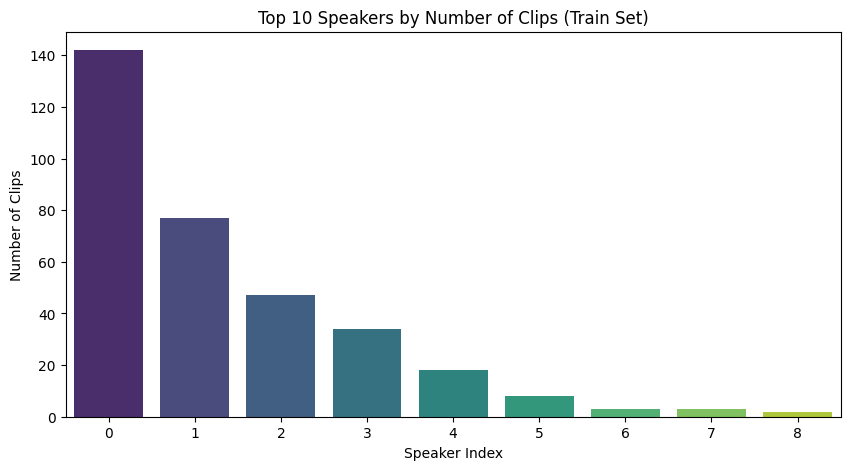

In [14]:
plt.figure(figsize=(10, 5))

top_counts = speaker_counts.iloc[:10].values
x_labels = range(len(top_counts))

sns.barplot(x=x_labels, y=top_counts, palette="viridis")

plt.title("Top 10 Speakers by Number of Clips (Train Set)")
plt.xlabel("Speaker Index")
plt.ylabel("Number of Clips")

plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_9596\164373501.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x='gender', ax=axes[0], palette="pastel", order=train['gender'].value_counts().index)
C:\Users\Asus\AppData\Local\Temp\ipykernel_9596\164373501.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x='age', ax=axes[1], palette="pastel", order=train['age'].value_counts().index)


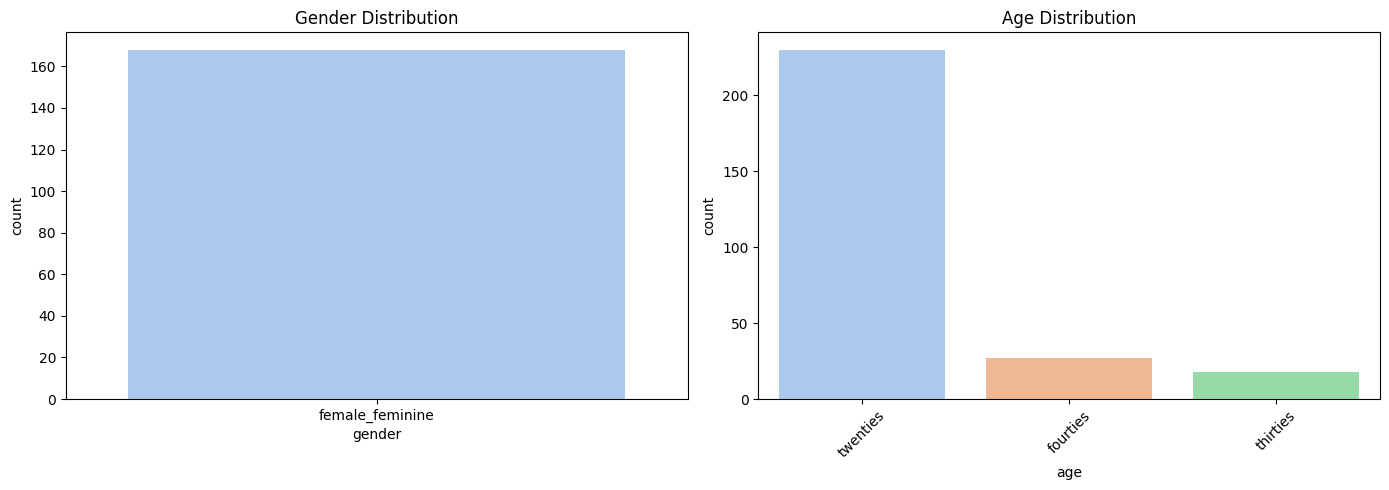

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=train, x='gender', ax=axes[0], palette="pastel", order=train['gender'].value_counts().index)
axes[0].set_title("Gender Distribution")

sns.countplot(data=train, x='age', ax=axes[1], palette="pastel", order=train['age'].value_counts().index)
axes[1].set_title("Age Distribution")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_9596\4060207781.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=test, x='gender', ax=axes[0], palette="pastel", order=train['gender'].value_counts().index)
C:\Users\Asus\AppData\Local\Temp\ipykernel_9596\4060207781.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=test, x='age', ax=axes[1], palette="pastel", order=train['age'].value_counts().index)


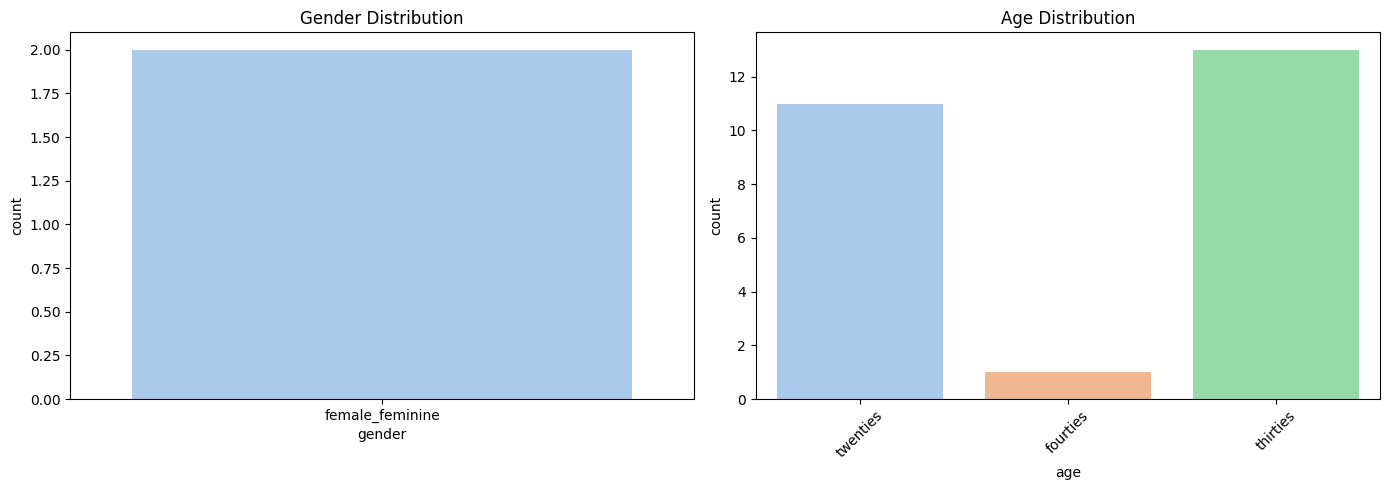

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=test, x='gender', ax=axes[0], palette="pastel", order=train['gender'].value_counts().index)
axes[0].set_title("Gender Distribution")

sns.countplot(data=test, x='age', ax=axes[1], palette="pastel", order=train['age'].value_counts().index)
axes[1].set_title("Age Distribution")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_9596\2295534356.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=validated, x='gender', ax=axes[0], palette="pastel", order=train['gender'].value_counts().index)
C:\Users\Asus\AppData\Local\Temp\ipykernel_9596\2295534356.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=validated, x='age', ax=axes[1], palette="pastel", order=train['age'].value_counts().index)


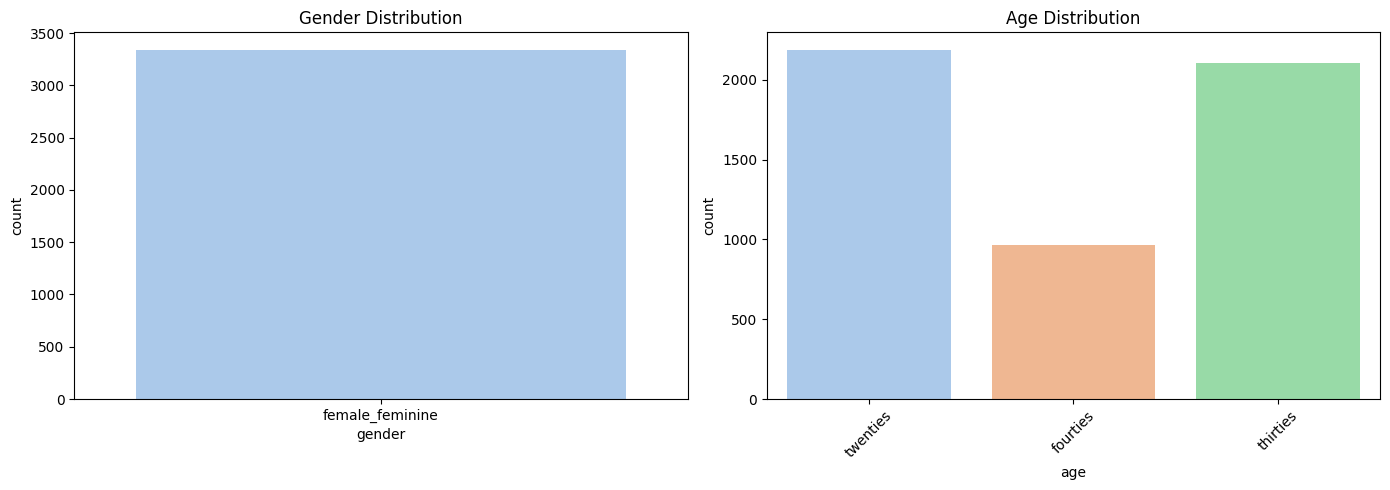

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=validated, x='gender', ax=axes[0], palette="pastel", order=train['gender'].value_counts().index)
axes[0].set_title("Gender Distribution")

sns.countplot(data=validated, x='age', ax=axes[1], palette="pastel", order=train['age'].value_counts().index)
axes[1].set_title("Age Distribution")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### IMPORTANT : Gender, sentence_domain, accents, variant and segment columns has lots of NaNs

#### Gender: NaN s are probably voices of Male (TODO)
#### Sentence domain, Variant and Segment is fully NaN columns
#### Age misses some columns manually

In [18]:
train.isna().sum()

client_id            0
path                 0
sentence_id          0
sentence             0
sentence_domain    333
up_votes             0
down_votes           0
age                 59
gender             166
accents            115
variant            334
locale               0
segment            334
duration[ms]         0
dtype: int64

▶️ Play audio for sample 1:


▶️ Play audio for sample 2:


▶️ Play audio for sample 3:


▶️ Play audio for sample 4:


▶️ Play audio for sample 5:


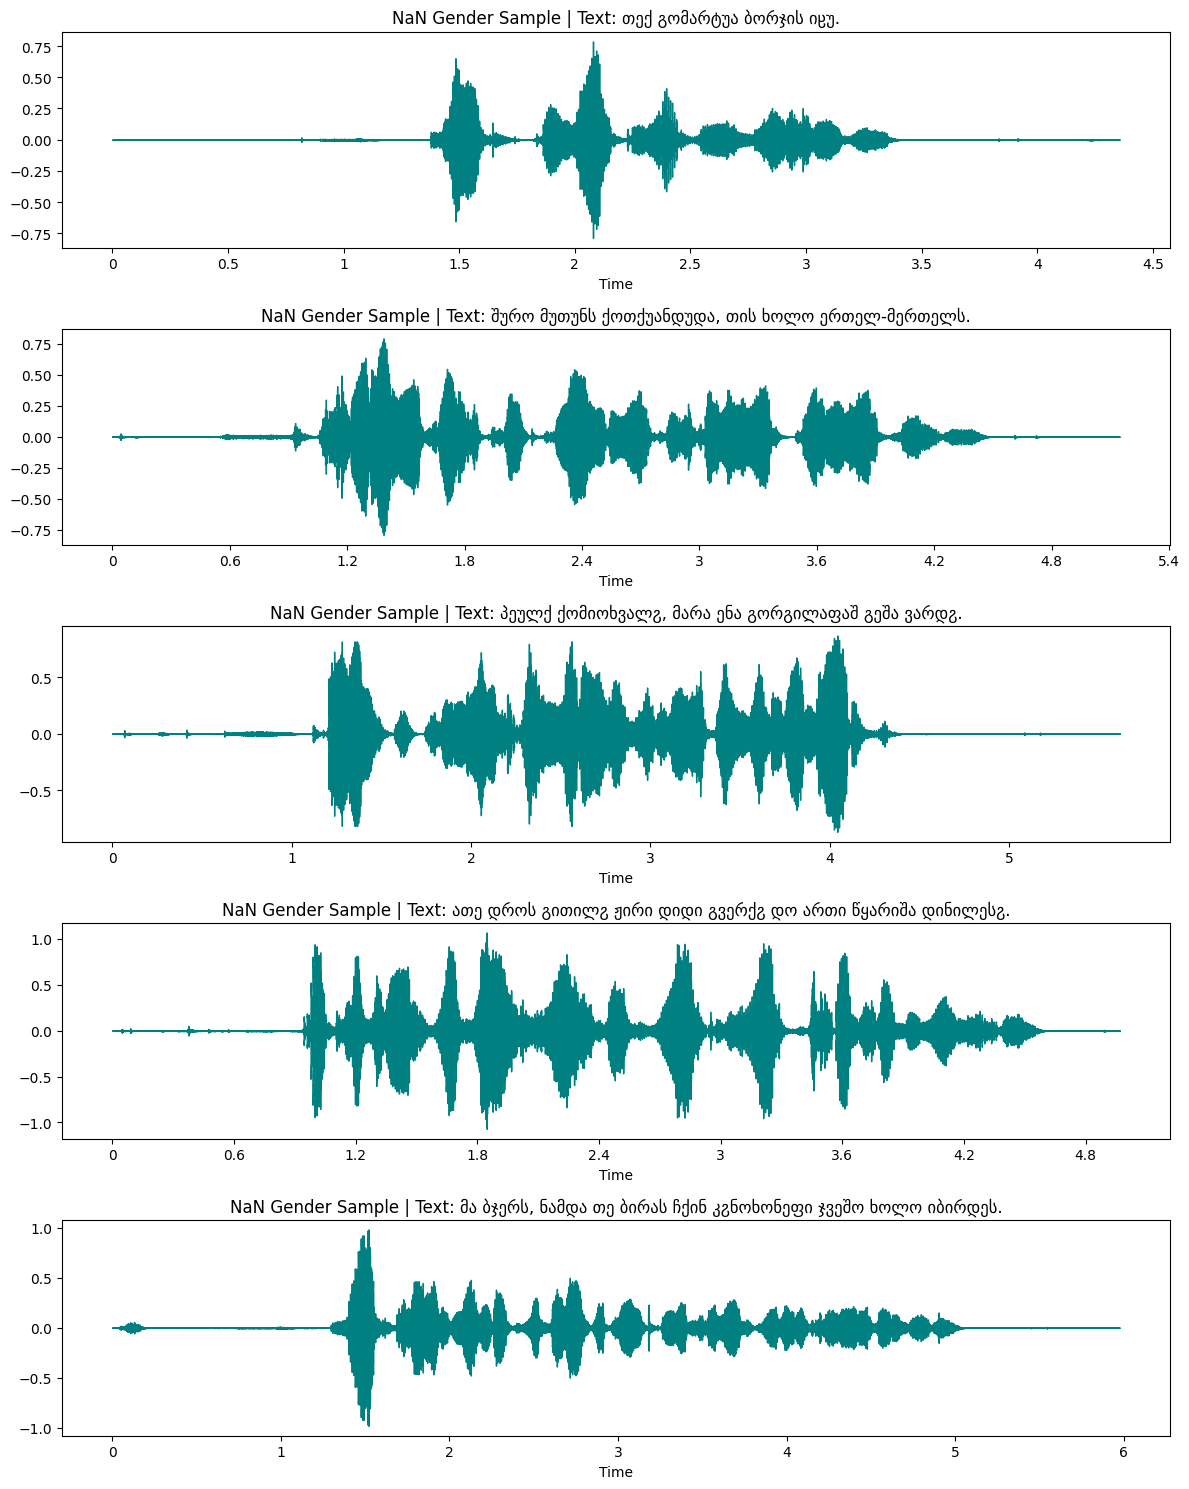

In [22]:
nan_gender_samples = train[train['gender'].isna()].head(5)

final_samples = []
for _, row in nan_gender_samples.iterrows():
    audio_path = os.path.join(clips_path, row['path'])
    y, sr = librosa.load(audio_path, sr=None)
    final_samples.append((row.get('sentence', 'N/A'), row, y, sr))

if final_samples:
    fig, axes = plt.subplots(len(final_samples), 1, figsize=(12, 3 * len(final_samples)))
    
    if len(final_samples) == 1:
        axes = [axes]

    for i, (char, row, y, sr) in enumerate(final_samples):
        librosa.display.waveshow(y, sr=sr, ax=axes[i], color="teal")
        axes[i].set_title(f"NaN Gender Sample | Text: {row['sentence']}")
        
        print(f"▶️ Play audio for sample {i+1}:")
        display(Audio(data=y, rate=sr))

    plt.tight_layout()
    plt.show()

### NaN s are Male

### Data Leakage Check

In [19]:
train_speakers = set(train['client_id'])
dev_speakers = set(dev['client_id'])
test_speakers = set(test['client_id'])

leakage_dev = train_speakers.intersection(dev_speakers)
leakage_test = train_speakers.intersection(test_speakers)
print(f"Speakers in BOTH Train and Dev: {len(leakage_dev)}")
print(f"Speakers in BOTH Train and Test: {len(leakage_test)}\n")

Speakers in BOTH Train and Dev: 0
Speakers in BOTH Train and Test: 0



In [20]:
train

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment,duration[ms]
0,7805b6a0fad5179e158296a21de58b5fe3c805e92c0f78...,common_voice_xmf_42539060.mp3,e65d9da56b5c947c57cdbb5dcb37d69cbebb780934abeb...,თექ გომარტუა ბორჯის იჸუ.,NaN,4,0,twenties,NaN,"ზუგიდური, ზუგიდური",NaN,xmf,NaN,4356
1,7805b6a0fad5179e158296a21de58b5fe3c805e92c0f78...,common_voice_xmf_42539155.mp3,aa4a96d201ace9fda943f149b3640a5e0e53f36a667efb...,"შურო მუთუნს ქოთქუანდუდა, თის ხოლო ერთელ-მერთელს.",NaN,4,0,twenties,NaN,"ზუგიდური, ზუგიდური",NaN,xmf,NaN,5148
2,7805b6a0fad5179e158296a21de58b5fe3c805e92c0f78...,common_voice_xmf_42539230.mp3,0f641fd3482f0b33a160ab18a40d788bce608666abf521...,"პეულქ ქომიოხვალჷ, მარა ენა გორგილაფაშ გეშა ვარდჷ.",NaN,4,0,twenties,NaN,"ზუგიდური, ზუგიდური",NaN,xmf,NaN,5616
3,7805b6a0fad5179e158296a21de58b5fe3c805e92c0f78...,common_voice_xmf_42539233.mp3,d6245987e631406c36c86f17c888a750904511e41bec29...,ათე დროს გითილჷ ჟირი დიდი გვერქჷ დო ართი წყარი...,NaN,4,0,twenties,NaN,"ზუგიდური, ზუგიდური",NaN,xmf,NaN,4968
4,7805b6a0fad5179e158296a21de58b5fe3c805e92c0f78...,common_voice_xmf_42539260.mp3,0b198f74c954977238cf0789dec02b06c3a7cdded70f5b...,"მა ბჯერს, ნამდა თე ბირას ჩქინ კჷნოხონეფი ჯვეშო...",NaN,4,0,twenties,NaN,"ზუგიდური, ზუგიდური",NaN,xmf,NaN,5976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,2c65379fbc80576c83aa9440b32d8ab7cab2956b0a218e...,common_voice_xmf_42377384.mp3,f1b4e41200a68e15aa54dc59ed54222e8db89b51772215...,გერეშ გერე ირო იინია,NaN,2,0,thirties,NaN,NaN,NaN,xmf,NaN,2916
330,2c65379fbc80576c83aa9440b32d8ab7cab2956b0a218e...,common_voice_xmf_42393717.mp3,72956a16cb105b7856af4bd3d75581bd55729b41d85686...,პეარლ კოჩ,NaN,2,1,thirties,NaN,NaN,NaN,xmf,NaN,1836
331,2c65379fbc80576c83aa9440b32d8ab7cab2956b0a218e...,common_voice_xmf_42603279.mp3,b8a2678ff867a77c58fb386c5ced949636a96216afcb38...,თენა ოწმახო რდჷ თაშ მონწყილი.,NaN,2,0,thirties,NaN,NaN,NaN,xmf,NaN,3096
332,8f8ff3d876f1b239fbf93de2c1db320ce608d4a682f71c...,common_voice_xmf_42351698.mp3,0c9d79f4750f72394961662cc858fd365b2ed78684602f...,მუსორთუქქ,NaN,2,1,thirties,female_feminine,NaN,NaN,xmf,NaN,2520


In [21]:
for df in [train, dev, test]:
    if 'duration[ms]_x' in df.columns:
        df['duration_sec'] = df['duration[ms]_x'] / 1000.0

train['word_count'] = train['sentence'].apply(lambda x: len(str(x).split()))
train['speech_rate'] = train['word_count'] / train['duration_sec']

print(f"Average words per sentence: {train['word_count'].mean():.1f}")
print(f"Average speech rate (words/sec): {train['speech_rate'].mean():.2f}\n")

KeyError: 'duration_sec'

### Speech rate (Wp/S)

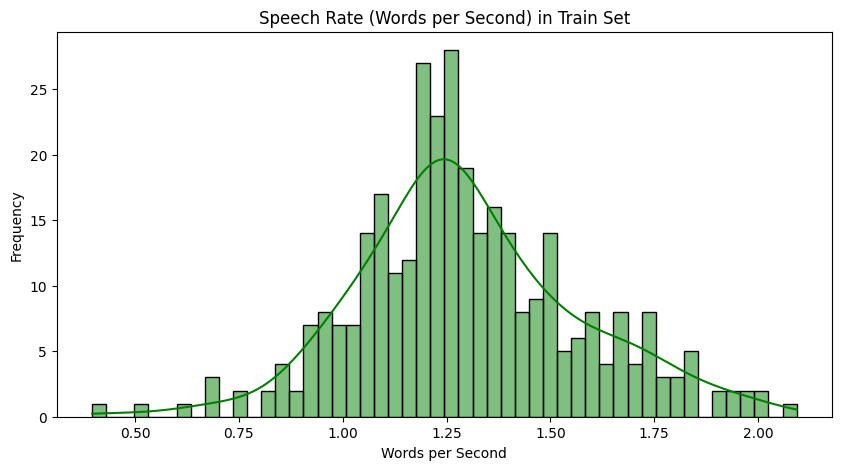

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(train['speech_rate'].dropna(), bins=50, color='green', kde=True)
plt.title("Speech Rate (Words per Second) in Train Set")
plt.xlabel("Words per Second")
plt.ylabel("Frequency")
plt.show()

In [ ]:
unique_sentences = train['sentence'].nunique()
print(f"Unique sentences in Train: {unique_sentences} out of {len(train)} total rows.")
print(f"Percentage of unique text: {(unique_sentences/len(train))*100:.1f}%\n")

Unique sentences in Train: 334 out of 334 total rows.
Percentage of unique text: 100.0%



### Validated VS Invalidated

Total Validated Clips: 6753
Total Invalidated Clips: 587
Invalidation Rate: 8.00%



C:\Users\Asus\AppData\Local\Temp\ipykernel_23736\854639083.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Validated', 'Invalidated'], y=[val_count, inval_count], palette=['#2ecc71', '#e74c3c'])


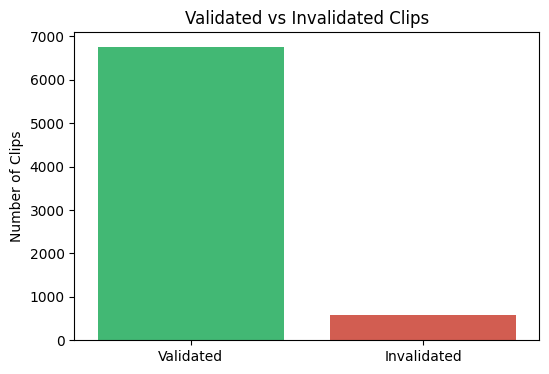

In [ ]:
val_count = len(validated)
inval_count = len(invalidated)
total_reviewed = val_count + inval_count

print(f"Total Validated Clips: {val_count}")
print(f"Total Invalidated Clips: {inval_count}")
if total_reviewed > 0:
    print(f"Invalidation Rate: {(inval_count / total_reviewed) * 100:.2f}%\n")

# Plot Validated vs Invalidated
plt.figure(figsize=(6, 4))
sns.barplot(x=['Validated', 'Invalidated'], y=[val_count, inval_count], palette=['#2ecc71', '#e74c3c'])
plt.title("Validated vs Invalidated Clips")
plt.ylabel("Number of Clips")
plt.show()
